# Modelacion de sismogramas campo lejano

**Curso:** ______________________________  
**Estudiante:** _________________________  
**Fecha:** ______________________________

---

## Descripción

En esta tarea se estudiará de manera práctica la **modelación de sismogramas en campo lejano** mediante un código numérico proporcionado junto con este notebook.

El objetivo general es familiarizarse con el flujo de trabajo típico asociado a un programa de modelación sismológica:

1. revisar los archivos de entrada;
2. compilar el código fuente utilizando un `Makefile`;
3. ejecutar el programa;
4. inspeccionar los archivos de salida;
5. analizar e interpretar los sismogramas obtenidos.

> **Importante:** antes de ejecutar el notebook, verifique que todos los archivos requeridos por el programa se encuentren en las rutas indicadas.


## Objetivos de la tarea

Al finalizar esta actividad, se espera que el estudiante sea capaz de:

- identificar los principales parámetros utilizados en una modelación de sismogramas de campo lejano;
- compilar un programa científico mediante un `Makefile`;
- ejecutar el modelo desde un entorno Jupyter;
- revisar los archivos producidos durante la simulación;
- representar e interpretar los resultados obtenidos.


## Esquema del problema

Inserte en este espacio una figura que describa el problema físico, la geometría de la fuente, las estaciones o el procedimiento de modelación.

Para utilizar una imagen almacenada en el repositorio, puede reemplazar la ruta del siguiente ejemplo:

```markdown
![Esquema de la modelación](figuras/esquema_modelacion.png)
```

<!-- Descomentar y modificar cuando la figura esté disponible:

![Esquema de la modelación](figuras/esquema_modelacion.png)

-->


## 1. Preparación del entorno

La siguiente celda permite verificar el directorio de trabajo y listar los archivos disponibles.

La estructura del repositorio podría ser, por ejemplo:

```text
repositorio/
├── Modelacion_sismogramas_campo_lejano.ipynb
├── Makefile
├── src/
├── datos/
├── figuras/
└── programa
```

Adapte los nombres y rutas según la organización definitiva del repositorio.


In [36]:
from pathlib import Path

directorio = Path.cwd()

print(f"Directorio de trabajo: {directorio}\n")
print("Archivos disponibles:")
for archivo in sorted(directorio.iterdir()):
    print(f"  {archivo.name}")


Directorio de trabajo: /home/tata/Dropbox/TELESEIS/Version_2026/teleseis

Archivos disponibles:
  .directory
  CMLA.0
  CMLA.1
  CMLA.2
  CMLA.txt
  Makefile
  Modelacion_sismogramas_campo_lejano.ipynb
  NOUC.txt
  RAR.0
  RAR.1
  RAR.2
  RAR.txt
  RSSD.txt
  SHEL.0
  SHEL.1
  SHEL.2
  SHEL.txt
  WVT.0
  WVT.1
  WVT.2
  WVT.txt
  inputs_ejemplo.txt
  plot01_np.py
  plot02_np.py
  plot0_np.py
  readme
  sac
  src
  teleseis3_2
  vm_prem.txt
  vmodel_tel


## 2. Compilación del programa

El código fuente se compila utilizando el `Makefile` incluido en el repositorio.

La opción `make clean` se ejecuta primero para eliminar archivos generados por compilaciones anteriores. Si el `Makefile` no contiene una regla `clean`, puede comentar esa línea.


In [37]:
# Limpiar una compilación anterior, si existe la regla "clean"
!make clean

# Compilar el programa
!make


rm -f teleseis3_2 src/*.o *~ core
gfortran -C -O -g -w -c src/getgeomnew.f -o src/getgeomnew.o
gfortran -C -O -g -w -c src/sub.bodyw3.f -o src/sub.bodyw3.o
gfortran -C -O -g -w -c src/sub.cfft.f -o src/sub.cfft.o
gfortran -C -O -g -w -c src/sub.clear.f -o src/sub.clear.o
gfortran -C -O -g -w -c src/sub.cnvr.f -o src/sub.cnvr.o
gfortran -C -O -g -w -c src/sub.cnvrsh.f -o src/sub.cnvrsh.o
gfortran -C -O -g -w -c src/sub.instg.f -o src/sub.instg.o
gfortran -C -O -g -w -c src/sub.prod.f -o src/sub.prod.o
gfortran -C -O -g -w -c src/sub.qf.f -o src/sub.qf.o
gfortran -C -O -g -w -c src/sub.radp3.f -o src/sub.radp3.o
gfortran -C -O -g -w -c src/sub.refl.f -o src/sub.refl.o
gfortran -C -O -g -w -c src/sub.reflsh.f -o src/sub.reflsh.o
gfortran -C -O -g -w -c src/sub.stf_add.f -o src/sub.stf_add.o
gfortran -C -O -g -w -c src/sub.fourt.f -o src/sub.fourt.o
gfortran -C -O -g -w -c src/sub.bpfilter.f -o src/sub.bpfilter.o
gfortran -C -O -g -w -o teleseis3_2 src/teleseis3_2.f src/getgeomnew.o src/su

### Verificación

Compruebe que la compilación terminó sin errores y que se generó el ejecutable esperado.

**Pregunta 1.** ¿Qué compilador se utiliza en el `Makefile`?  
**Respuesta:**  

**Pregunta 2.** ¿Qué archivos fuente participan en la compilación?  
**Respuesta:**  

**Pregunta 3.** ¿Cuál es el nombre del ejecutable generado?  
**Respuesta:**  


## 3. Ejecución del modelo

Modifique `NOMBRE_EJECUTABLE` para que coincida con el nombre del programa generado por el `Makefile`.

Si el programa recibe argumentos o archivos de entrada, agréguelos en la línea de ejecución.


In [38]:
NOMBRE_EJECUTABLE = "teleseis3_2"

# Ejemplo con un archivo de entrada:
!./{NOMBRE_EJECUTABLE} < inputs_ejemplo.txt


## 4. Revisión de los resultados

Utilice la siguiente celda para inspeccionar los archivos generados por el programa.

Cambie el directorio `salida/` si el programa escribe sus resultados en otra ubicación.


In [39]:
from pathlib import Path

directorio_salida = Path("salida")

if directorio_salida.exists():
    print("Archivos de salida:")
    for archivo in sorted(directorio_salida.iterdir()):
        print(f"  {archivo}")
else:
    print(
        "No existe el directorio 'salida/'. "
        "Modifique 'directorio_salida' de acuerdo con la configuración del programa."
    )


No existe el directorio 'salida/'. Modifique 'directorio_salida' de acuerdo con la configuración del programa.


## 5. Análisis de los sismogramas

En esta sección se deberán cargar y representar los sismogramas obtenidos.

Complete la siguiente celda utilizando el formato real de los archivos de salida.


In [40]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# EJEMPLO:
#
# datos = np.loadtxt("salida/sismograma.dat")
# tiempo = datos[:, 0]
# amplitud = datos[:, 1]
#
# plt.figure(figsize=(10, 4))
# plt.plot(tiempo, amplitud)
# plt.xlabel("Tiempo [s]")
# plt.ylabel("Amplitud")
# plt.title("Sismograma sintético")
# plt.grid(alpha=0.3)
# plt.show()
# -------------------------------------------------------------------------

print("Complete esta celda con la lectura y visualización de los sismogramas.")


Complete esta celda con la lectura y visualización de los sismogramas.


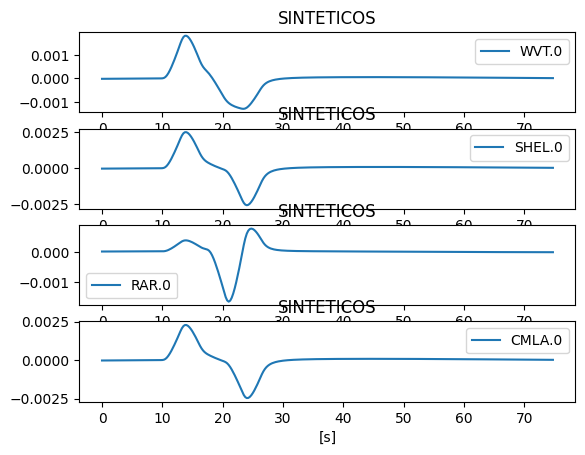

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMETROS

largo = 300 #200

# LECTURA NOMBRE ESTACIONES
stn_file = 'inputs_ejemplo.txt'

with open(stn_file,'r') as f:
    lines = f.readlines()[5:]

TXT = [stn + '.0' for stn in [l.rsplit()[2] for l in lines]]

#PLOTEO 
fig = plt.figure()

for i,txtfile in enumerate(TXT):
    ax1 = fig.add_subplot(len(TXT),1, i+1)

    data = np.loadtxt(txtfile)
    x, y = data[:largo,0], data[:largo,1]
    ax1.plot(x, y, label=txtfile)

    ax1.set_title('SINTETICOS')
    ax1.set_xlabel('[s]')
    ax1.legend(prop={'size':10})

plt.show()

RMS WVT 15.4813285888568
RMS SHEL 12.061486538038304
RMS RAR 10.964613484447602
RMS CMLA 10.220787609341073


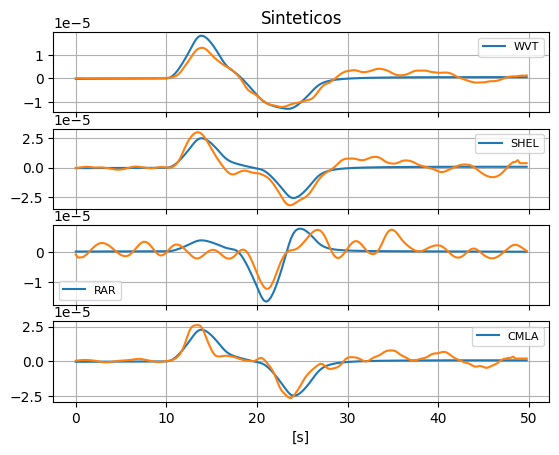

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import os

# PARAMETROS
largo = 270
largo = 200


# LECTURA NOMBRE ESTACIONES
stn_file = 'inputs_ejemplo.txt'

with open(stn_file,'r') as f:
    lines = f.readlines()[5:]

TXT = os.listdir('.')
TXT = [l for l in TXT if l[-4:] == '.txt']

OUT = [stn + '.0' for stn in [l.rsplit()[2] for l in lines]]


#PLOTEO 
fig = plt.figure()

for i,txtfile in enumerate(OUT):
    ax1 = fig.add_subplot(len(OUT),1, i+1)

    data = np.loadtxt(txtfile)
    x, y = data[:largo,0], data[:largo,1]

    stn = txtfile.rsplit('.')[0]

    if i == 0:
        ax1.set_title('Sinteticos')

    ax1.plot(x,y/100., label=stn)
    ax1.legend(prop={'size':8})


    if i == len(OUT) - 1:
        ax1.set_xlabel('[s]')
    else:
        ax1.axes.xaxis.set_ticklabels([])

    ax1.grid()

    ot = [l for l in TXT if stn in l][0]
    datao = np.loadtxt(ot)

    # Grafico waveform
    yo = datao
    x = np.linspace(0,len(yo)/4,len(yo) + 1)[:-1]  #datos sin tiempo 
    ax1.plot(x[0:largo],yo[0:largo], label=stn)

    print('RMS ' + stn, np.sqrt((np.sum(y[:largo]-yo[:largo])**2)/sum(yo[:largo]**2)))

plt.show()

## 6. Preguntas de análisis

Responda brevemente las siguientes preguntas utilizando los resultados obtenidos.

**Pregunta 4.** ¿Qué características principales observa en el sismograma sintético?  

**Respuesta:**  


**Pregunta 5.** ¿Cómo cambian los resultados al modificar los parámetros de la fuente o del medio?  

**Respuesta:**  


**Pregunta 6.** ¿Qué aproximaciones asociadas al campo lejano están implícitas en esta modelación?  

**Respuesta:**  


**Pregunta 7.** Comente las principales limitaciones del procedimiento utilizado.  

**Respuesta:**  


## 7. Entrega

La entrega debe contener:

- este notebook ejecutado;
- los archivos de entrada utilizados;
- las figuras generadas;
- las respuestas a las preguntas;
- cualquier modificación realizada al código o al `Makefile`.

Antes de subir los archivos al repositorio, compruebe que el notebook pueda ejecutarse desde el inicio utilizando:

**Kernel → Restart & Run All**

y que no dependa de rutas absolutas específicas de su computador.
